Import libraries

In [34]:
import pandas as pd
import mysql.connector
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

Connect to MySQL and create schema

In [ ]:
DB_CONFIG = {
    'host': 'localhost',
    'user': 'root',
    'password': '********'
}
db = mysql.connector.connect(**DB_CONFIG)
cursor = db.cursor()

# Create schema if not exists
cursor.execute("CREATE DATABASE IF NOT EXISTS mapping_db;")
cursor.execute("USE mapping_db;")

# Create data tables
cursor.execute(""" CREATE TABLE IF NOT EXISTS train_data (
    x float PRIMARY KEY,
    y1 float, y2 float, y3 float, y4 float
); """)
cursor.execute(""" CREATE TABLE IF NOT EXISTS test_data (
    x float,
    y float,
    primary key (x, y)
); """)
cursor.execute(""" CREATE TABLE IF NOT EXISTS ideal_data (
    x float PRIMARY KEY,
    y1 float, y2 float, y3 float, y4 float, y5 float, y6 float, y7 float, y8 float, y9 float, y10 float,
    y11 float, y12 float, y13 float, y14 float, y15 float, y16 float, y17 float, y18 float, y19 float, y20 float,
    y21 float, y22 float, y23 float, y24 float, y25 float, y26 float, y27 float, y28 float, y29 float, y30 float,
    y31 float, y32 float, y33 float, y34 float, y35 float, y36 float, y37 float, y38 float, y39 float, y40 float,
    y41 float, y42 float, y43 float, y44 float, y45 float, y46 float, y47 float, y48 float, y49 float, y50 float
); """)

# Create additional tables

# best fit mapping train_func (eg y1), ideal_func (eg y24)
cursor.execute(""" CREATE TABLE IF NOT EXISTS best_fit_mapping (
    train_func VARCHAR(10),
    ideal_func VARCHAR(10),
    error FLOAT
); """)

cursor.execute(""" CREATE TABLE IF NOT EXISTS test_mapping (
    test_x FLOAT,
    test_y FLOAT,
    ideal_func VARCHAR(10),
    ideal_y FLOAT,
    deviation FLOAT
);
 """)

# source: 'train' or 'test'
cursor.execute(""" CREATE TABLE IF NOT EXISTS deviation_results (
    source VARCHAR(20),        
    func VARCHAR(10),
    x FLOAT,
    y_actual FLOAT,
    y_pred FLOAT,
    deviation FLOAT
); """)
db.commit()

Load the dataset (CSV files)

In [29]:
train_df = pd.read_csv('dataset/train.csv')
print("Shape: ", train_df.shape)
print("---------------------------------------------")
print("Columns: ", train_df.columns)
print("---------------------------------------------")
print("Description: ", train_df.describe())
print("---------------------------------------------")
print("Info: ")
train_df.info()
print("---------------------------------------------")
print("Head: ", train_df.head())
print("---------------------xx------------------------")


Shape:  (400, 5)
---------------------------------------------
Columns:  Index(['x', 'y1', 'y2', 'y3', 'y4'], dtype='object')
---------------------------------------------
Description:                 x          y1          y2          y3          y4
count  400.00000  400.000000  400.000000  400.000000  400.000000
mean    -0.05000    0.107666   -0.094239   -0.051628    0.012633
std     11.56143   23.103285   23.111794   11.560369    0.327063
min    -20.00000  -39.724934  -40.078590  -20.214268   -0.744510
25%    -10.02500  -20.312566  -19.642560   -9.999807   -0.198240
50%     -0.05000    0.367844   -0.000603   -0.155205    0.024634
75%      9.92500   19.606209   19.478971    9.992209    0.236008
max     19.90000   40.151100   40.558865   19.840752    0.742489
---------------------------------------------
Info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  ----- 

In [30]:
test_df = pd.read_csv('dataset/test.csv')
print("Shape: ", test_df.shape)
print("---------------------------------------------")
print("Columns: ", test_df.columns)
print("---------------------------------------------")
print("Description: ", test_df.describe())
print("---------------------------------------------")
print("Info: ")
test_df.info()
print("---------------------------------------------")
print("Head: ", test_df.head())
print("---------------------xx------------------------")


Shape:  (100, 2)
---------------------------------------------
Columns:  Index(['x', 'y'], dtype='object')
---------------------------------------------
Description:                  x           y
count  100.000000  100.000000
mean     0.299000    0.325483
std     12.039501   20.745993
min    -20.000000  -40.449770
25%     -9.775000  -14.091911
50%     -0.500000   -0.038432
75%     11.700000   15.968556
max     19.700000   38.955273
---------------------------------------------
Info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       100 non-null    float64
 1   y       100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB
---------------------------------------------
Head:        x          y
0  17.5  34.161040
1   0.3   1.215102
2  -8.7 -16.843908
3 -19.2 -37.170870
4 -11.0 -20.263054
---------------------xx------------------------


In [31]:
ideal_df = pd.read_csv('dataset/ideal.csv')
print("Shape: ", ideal_df.shape)
print("---------------------------------------------")
print("Columns: ", ideal_df.columns)
print("---------------------------------------------")
print("Description: ", ideal_df.describe())
print("---------------------------------------------")
print("Info: ")
ideal_df.info()
print("---------------------------------------------")
print("Head: ", ideal_df.head())
print("---------------------xx------------------------")


Shape:  (400, 51)
---------------------------------------------
Columns:  Index(['x', 'y1', 'y2', 'y3', 'y4', 'y5', 'y6', 'y7', 'y8', 'y9', 'y10', 'y11',
       'y12', 'y13', 'y14', 'y15', 'y16', 'y17', 'y18', 'y19', 'y20', 'y21',
       'y22', 'y23', 'y24', 'y25', 'y26', 'y27', 'y28', 'y29', 'y30', 'y31',
       'y32', 'y33', 'y34', 'y35', 'y36', 'y37', 'y38', 'y39', 'y40', 'y41',
       'y42', 'y43', 'y44', 'y45', 'y46', 'y47', 'y48', 'y49', 'y50'],
      dtype='object')
---------------------------------------------
Description:                 x          y1          y2          y3          y4          y5  \
count  400.00000  400.000000  400.000000  400.000000  400.000000  400.000000   
mean    -0.05000   -0.002282    0.045609    9.997718    5.045609   -9.997718   
std     11.56143    0.701386    0.713074    0.701386    0.713074    0.701386   
min    -20.00000   -0.999990   -0.999968    9.000010    4.000032  -10.999990   
25%    -10.02500   -0.695113   -0.669387    9.304887    4.3306

Add datasets to db

In [32]:
def insert_dataframe(df, table_name):
    cols = ','.join(df.columns)
    # Data integrity: avoide duplicates
    # Try to insert data and rollback in case of duplicate primary key
    row_cnt=pd.read_sql(f"SELECT COUNT(*) FROM {table_name};", con=db).iloc[0,0]
    if row_cnt == len(df):
        print(f"Data already exists in {table_name}, skipping insertion.")
        return
    else:
        print(f"Inserting data into {table_name}...")
        try:
            for row in df.itertuples(index=False):
                placeholders = ','.join(['%s']*len(row))
                sql = f"INSERT INTO {table_name} ({cols}) VALUES ({placeholders})"
                cursor.execute(sql, row)
            db.commit()
        except mysql.connector.Error as err:
            print(f"Error: {err}")
            db.rollback()
# Insert
insert_dataframe(train_df, 'train_data')
insert_dataframe(ideal_df, 'ideal_data')
insert_dataframe(test_df, 'test_data')


Data already exists in train_data, skipping insertion.
Data already exists in ideal_data, skipping insertion.
Data already exists in test_data, skipping insertion.


C:\Users\Himanshu Saxena\AppData\Local\Temp\ipykernel_18216\2433992041.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  row_cnt=pd.read_sql(f"SELECT COUNT(*) FROM {table_name};", con=db).iloc[0,0]


TRAIN DATA DESCRIBE:
                x          y1          y2          y3          y4
count  400.00000  400.000000  400.000000  400.000000  400.000000
mean    -0.05000    0.107666   -0.094239   -0.051628    0.012633
std     11.56143   23.103285   23.111794   11.560369    0.327063
min    -20.00000  -39.724934  -40.078590  -20.214268   -0.744510
25%    -10.02500  -20.312566  -19.642560   -9.999807   -0.198240
50%     -0.05000    0.367844   -0.000603   -0.155205    0.024634
75%      9.92500   19.606209   19.478971    9.992209    0.236008
max     19.90000   40.151100   40.558865   19.840752    0.742489
IDEAL DATA DESCRIBE:
                x          y1          y2          y3          y4          y5  \
count  400.00000  400.000000  400.000000  400.000000  400.000000  400.000000   
mean    -0.05000   -0.002282    0.045609    9.997718    5.045609   -9.997718   
std     11.56143    0.701386    0.713074    0.701386    0.713074    0.701386   
min    -20.00000   -0.999990   -0.999968    9.00001

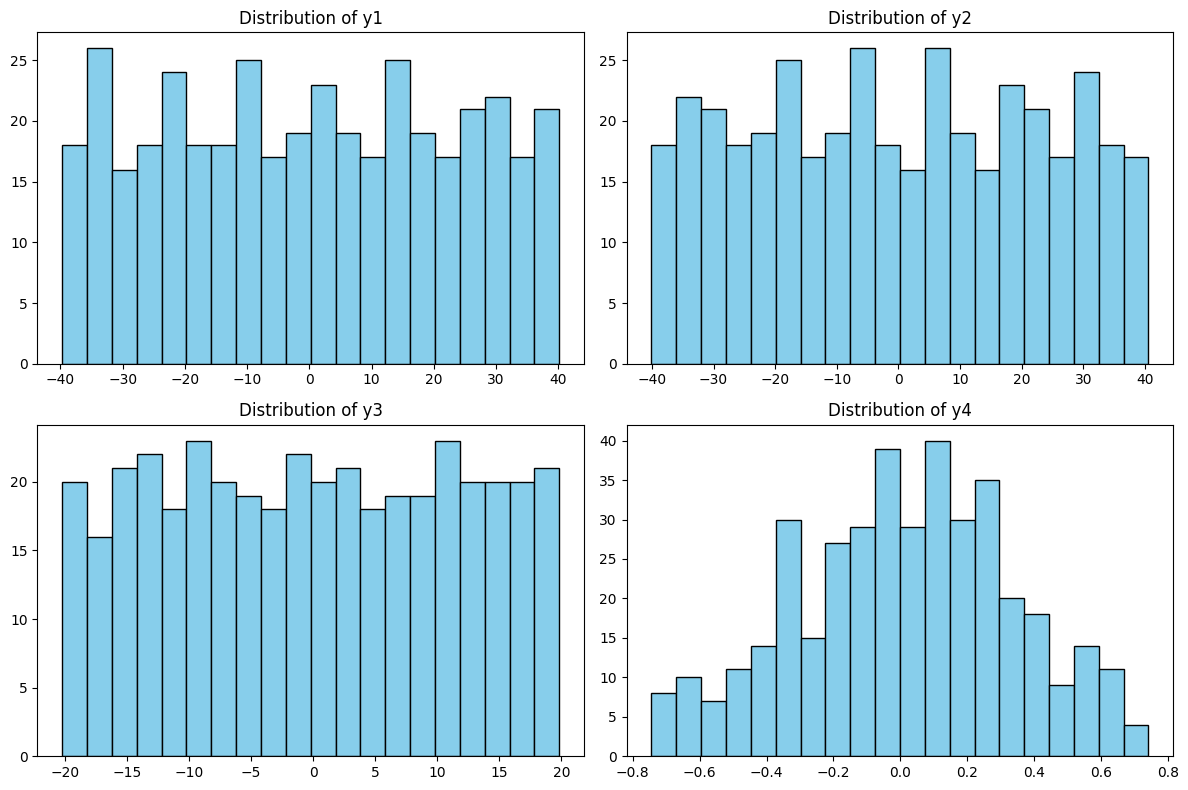

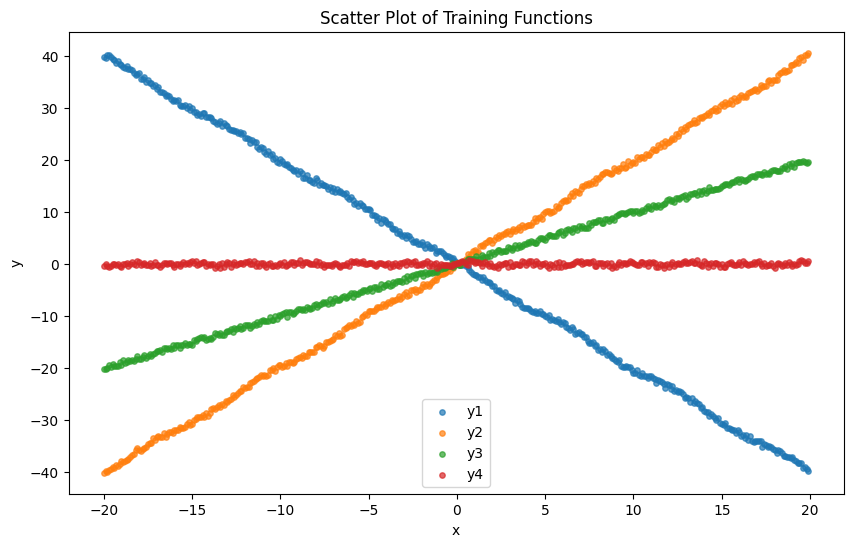

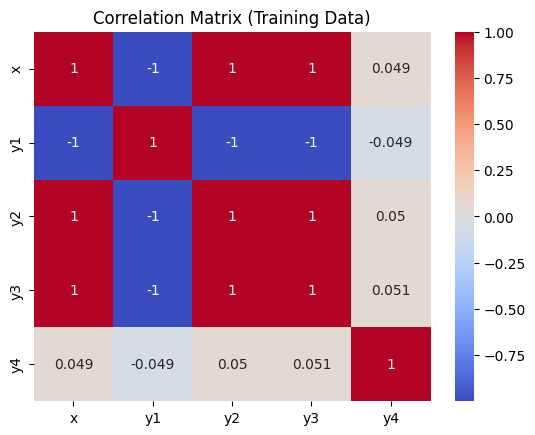

In [33]:

# Basic Summary Stats
print("TRAIN DATA DESCRIBE:\n", train_df.describe())
print("IDEAL DATA DESCRIBE:\n", ideal_df.describe())
print("TEST DATA DESCRIBE:\n", test_df.describe())

# Simple Null/NaN checks
print("Train missing values:\n", train_df.isnull().sum())
print("Ideal missing values:\n", ideal_df.isnull().sum())
print("Test missing values:\n", test_df.isnull().sum())

# Distribution Histogram for train y columns
fig, axes = plt.subplots(2,2, figsize=(12,8))
for idx, y in enumerate(['y1','y2','y3','y4']):
    ax = axes[idx//2, idx%2]
    ax.hist(train_df[y], bins=20, color='skyblue', edgecolor='k')
    ax.set_title(f'Distribution of {y}')
plt.tight_layout()
plt.show()

# Scatter Plot: Each train function vs. x
plt.figure(figsize=(10,6))
for y in ['y1','y2','y3','y4']:
    plt.scatter(train_df['x'], train_df[y], label=y, alpha=0.7, s=15)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter Plot of Training Functions')
plt.legend()
plt.show()

# Correlation matrix (train)
corr = train_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix (Training Data)')
plt.show()


In [ ]:
# Get test data and ideal data
test_df = pd.read_sql('SELECT * FROM test_data', db)
ideal_df = pd.read_sql('SELECT * FROM ideal_data', db)

# For each training function (y1, y2, y3, y4)
regressors = {}
train_x = train_df[['x']]

for y_col in ['y1', 'y2', 'y3', 'y4']:
    reg = LinearRegression()
    reg.fit(train_x, train_df[y_col])
    regressors[y_col] = reg
    # Optional: Save predictions on train_df for visualizations, comparisons
    train_df[y_col + '_pred'] = reg.predict(train_x)

ideal_x = ideal_df[['x']]

best_fit_funcs = {}

for y_col in ['y1', 'y2', 'y3', 'y4']:
    min_err = float('inf')
    best_func = None
    # Predicted curve by regression
    pred_y = regressors[y_col].predict(ideal_x)
    for ideal_func in ideal_df.columns[1:]:
        mse = ((pred_y - ideal_df[ideal_func]) ** 2).sum()
        if mse < min_err:
            min_err = mse
            best_func = ideal_func
    best_fit_funcs[y_col] = (best_func, min_err)
    print(f"{y_col} best matched by {best_func} with error {min_err:.2f}")
    
"""
# Your best mapping, say: {'y1':'y24', ...}
best_funcs = {'y1':'y24', 'y2':'y37', 'y3':'y12', 'y4':'y41'}

# For each training function, get max deviation (can use your earlier mapping)
train_df = pd.read_sql('SELECT * FROM train_data', db)
max_devs = {}
for train_col, ideal_col in best_funcs.items():
    devs = np.abs(train_df[train_col] - ideal_df[ideal_col])
    max_devs[ideal_col] = devs.max()

# For each test sample, map to ideal
for row in test_df.itertuples(index=False):
    x_val, y_val = row
    match_found = False
    for ideal_col, max_dev in max_devs.items():
        # Find the closest x in ideal table
        ideal_y = ideal_df.loc[np.isclose(ideal_df['x'], x_val, atol=1e-4), ideal_col]
        if not ideal_y.empty:
            ideal_y_val = ideal_y.values[0]
            deviation = np.abs(y_val - ideal_y_val)
            if deviation <= (max_dev + np.sqrt(2)):
                cursor.execute("INSERT INTO test_mapping (test_x, test_y, ideal_func, ideal_y, deviation) VALUES (%s, %s, %s, %s, %s)",
                               (x_val, y_val, ideal_col, ideal_y_val, deviation))
                match_found = True
                break
    if not match_found:
        cursor.execute("INSERT INTO test_mapping (test_x, test_y, ideal_func, ideal_y, deviation) VALUES (%s, %s, NULL, NULL, NULL)", (x_val, y_val))
db.commit()

"""


y1: Coef=-1.9978981414416084, Intercept=0.007771154570419492
y2: Coef=1.998638834476341, Intercept=0.005692899286316749
y3: Coef=0.9996282494208694, Intercept=-0.0016468939664565155
y4: Coef=0.0013867573074022633, Intercept=0.012702145351320108


C:\Users\Himanshu Saxena\AppData\Local\Temp\ipykernel_18216\467200938.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  test_df = pd.read_sql('SELECT * FROM test_data', db)
C:\Users\Himanshu Saxena\AppData\Local\Temp\ipykernel_18216\467200938.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  ideal_df = pd.read_sql('SELECT * FROM ideal_data', db)


'\n# Your best mapping, say: {\'y1\':\'y24\', ...}\nbest_funcs = {\'y1\':\'y24\', \'y2\':\'y37\', \'y3\':\'y12\', \'y4\':\'y41\'}\n\n# For each training function, get max deviation (can use your earlier mapping)\ntrain_df = pd.read_sql(\'SELECT * FROM train_data\', db)\nmax_devs = {}\nfor train_col, ideal_col in best_funcs.items():\n    devs = np.abs(train_df[train_col] - ideal_df[ideal_col])\n    max_devs[ideal_col] = devs.max()\n\n# For each test sample, map to ideal\nfor row in test_df.itertuples(index=False):\n    x_val, y_val = row\n    match_found = False\n    for ideal_col, max_dev in max_devs.items():\n        # Find the closest x in ideal table\n        ideal_y = ideal_df.loc[np.isclose(ideal_df[\'x\'], x_val, atol=1e-4), ideal_col]\n        if not ideal_y.empty:\n            ideal_y_val = ideal_y.values[0]\n            deviation = np.abs(y_val - ideal_y_val)\n            if deviation <= (max_dev + np.sqrt(2)):\n                cursor.execute("INSERT INTO test_mapping (test_x,

In [11]:
def find_best_ideal_functions(train_df, ideal_df):
    best_funcs = {}
    for y_train in ['y1', 'y2', 'y3', 'y4']:
        min_error = float('inf')
        best_func = None
        for y_ideal in ideal_df.columns[1:]:  # Skip the 'x' column
            error = ((train_df[y_train] - ideal_df[y_ideal]) ** 2).sum()
            if error < min_error:
                min_error = error
                best_func = y_ideal
        best_funcs[y_train] = best_func
    return best_funcs

best_funcs = find_best_ideal_functions(train_df, ideal_df)
print("Best matching ideal functions:", best_funcs)


Best matching ideal functions: {'y1': 'y42', 'y2': 'y41', 'y3': 'y11', 'y4': 'y48'}
